In [ ]:
import sys
import os
import importlib
import anndata as ad
import pandas as pd
import scanpy as sc
import squidpy as sq


/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/squidpy/gr/_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  CAN_USE_SPARSE_ARRAY = Version(anndata.

In [2]:
import numpy as np
import random
np.random.seed(123)
random.seed(123)

In [3]:
sys.path.append(os.path.abspath("/Users/lakshmi_nccs/Desktop/NCCS/Projects/For_Publication/HNSCC_CosMx6k/helpers/"))
import helpers
importlib.reload(helpers)
import tcell_classifier
importlib.reload(tcell_classifier)

<module 'tcell_classifier' from '/Users/lakshmi_nccs/Desktop/NCCS/Projects/For_Publication/HNSCC_CosMx6k/helpers/tcell_classifier.py'>

In [4]:
data_dir = "/Users/lakshmi_nccs/Desktop/NCCS/Projects/Cosmx6k/processed_data/"
res_dir = "/Users/lakshmi_nccs/Desktop/NCCS/Projects/Cosmx6k/results/final/P1/"
if not (os.path.exists(res_dir)):
    os.makedirs(res_dir)

In [ ]:
d1 = ad.read_h5ad(data_dir+"s1.h5ad")
d2 = ad.read_h5ad(data_dir+"s2.h5ad")
adata = ad.concat([d1,d2], axis=0, keys=['s1', 's2'])
adata.obs_names_make_unique()
adata.obs['tma_sid'] = adata.obs.TMA.astype(str)+"_"+adata.obs.SID.astype(str)
adata.write(res_dir+"adata_tma12.h5ad")

In [ ]:
adata = ad.read_h5ad(res_dir+"adata_tma12.h5ad")
ex = "all"
adata_pp = helpers.preprocess(adata, res_dir, ex, True)
adata_pp.write_h5ad(res_dir+ex+"_adata_pp.h5ad")

In [ ]:
adata = ad.read_h5ad(res_dir+ ex + "_adata_pp.h5ad")
adata_bc = helpers.batch_correction(adata, "harmony", "TMA",npcs = None, dis_met = "canberra")
adata_bc.write(res_dir + ex + "_adata_harm.h5ad")

In [ ]:
ex = "all"
res = 2
adata_bc = ad.read_h5ad(res_dir+ ex + "_adata_harm.h5ad")
adata_clus = helpers.cluster(adata_bc,res)
adata, fdf = helpers.deg(adata_clus, "leiden")
adata.write_h5ad(res_dir+ex+"_adata_res_" + str(res) + ".h5ad")
fdf.to_excel(res_dir+ex+"_adata_res_" + str(res) + ".xlsx")

In [ ]:
ex = "all"
res = 2
adata = ad.read_h5ad(res_dir+ ex + "_adata_res_" + str(res) + ".h5ad")
fdf = pd.read_excel(res_dir+ex+ "_adata_res_" + str(res) + ".xlsx")
ct_marker_list = pd.read_excel("/Users/lakshmi_nccs/Desktop/NCCS/Projects/Helpers/Marker_List/CellTypeMarkers_1029.xlsx")
adata_ann, annres = helpers.hier_cluster_marker_annotate(adata, fdf, ct_marker_list, "ct", pvalcutoff=10)
adata_ann.write_h5ad(res_dir + ex + "_adata_res_" + str(res) + "_hier_annot.h5ad")
annres['data'].to_excel(res_dir + ex + "_adata_res_" + str(res) + "_hier_annot.xlsx")

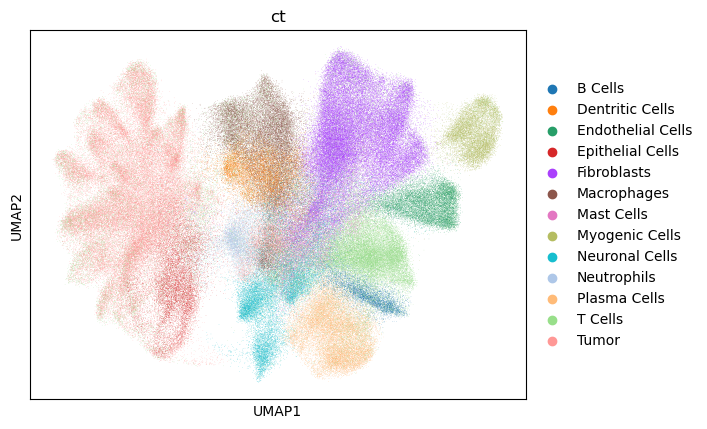

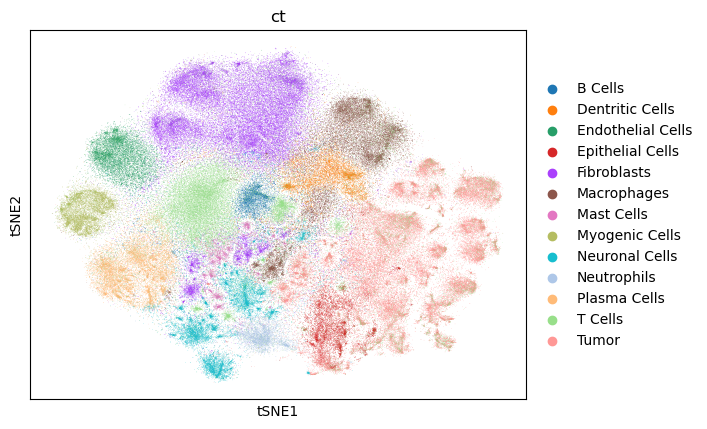

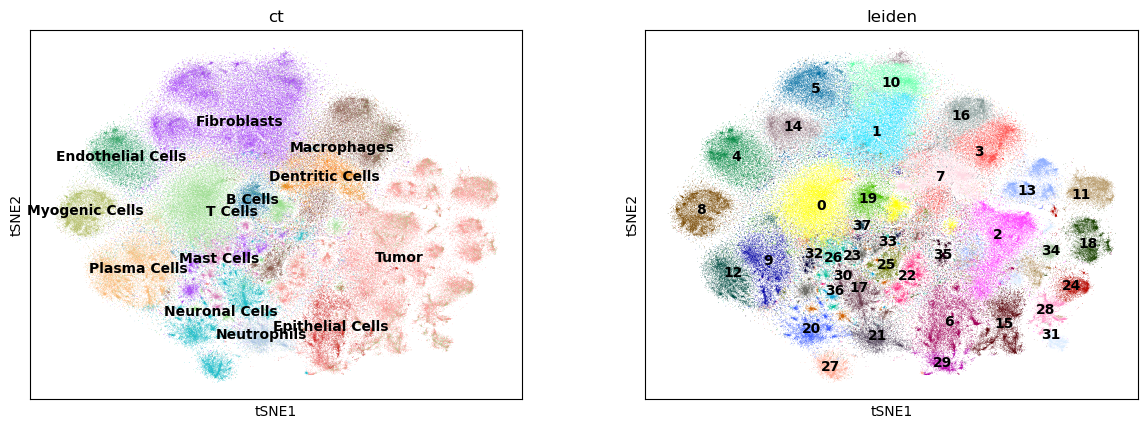

In [14]:
res = 2
ex = "all"
adata = ad.read_h5ad(res_dir + ex + "_adata_res_" + str(res) + "_hier_annot.h5ad")
sc.pl.umap(adata, color = ['ct'])
sc.pl.tsne(adata, color = ['ct'])
sc.pl.tsne(adata, color = ['ct', "leiden"], legend_loc="on data")

In [ ]:
fdf_top, expr_sum = helpers.deg_dotplot_summary(adata, 'ct', 5)
expr_sum.to_csv(res_dir + ex + "deg_dotplot_summary.csv")

In [ ]:
res = 2
ex = "all"
adata = ad.read_h5ad(res_dir + ex + "_adata_res_" + str(res) + "_hier_annot.h5ad")
sc.pl.umap(adata, color = ['ct'])

nm = "tcells"
tcells = adata[adata.obs["ct"] == "T Cells"]
tcells.obs['tcell_type'] = "NA"

Tmarkers2 = ['CD4']
Tmarkers3 = ['CD8A', 'CD8B']
mask2 = tcells.X[:,tcells.var_names.isin(Tmarkers2)].toarray() > 0
mask3 = tcells.X[:,tcells.var_names.isin(Tmarkers3)].toarray() > 0
sum(mask2.any(axis = 1) & mask3.any(axis=1))
sum(mask2.any(axis = 1) & ~mask3.any(axis=1))
sum(~mask2.any(axis = 1) & mask3.any(axis=1))
sum(~mask2.any(axis = 1) & ~mask3.any(axis=1))

tcells.obs.loc[mask2.any(axis = 1) & mask3.any(axis=1), 'tcell_type'] = "CD4+ CD8+"
tcells.obs.loc[mask2.any(axis = 1) & ~mask3.any(axis=1), 'tcell_type'] = "CD4+ CD8-"
tcells.obs.loc[~mask2.any(axis = 1) & mask3.any(axis=1), 'tcell_type'] = "CD4- CD8+"
tcells.obs.loc[~mask2.any(axis = 1) & ~mask3.any(axis=1), 'tcell_type'] = "CD4- CD8-"
tcells.write(res_dir+ nm + ".h5ad")

In [ ]:
nm = "tcells"
tcells = ad.read_h5ad(res_dir + nm+ ".h5ad")
tcells_harm = helpers.batch_correction(tcells, "harmony", "TMA")
tcells_harm.write_h5ad(res_dir + nm + "_harm.h5ad")

In [ ]:
metadata = ['Area', 'AspectRatio', 'Height', 'Width', 'NucArea', 'NucAspectRatio',
            'Circularity', 'Eccentricity', 'Perimeter', 'n_genes_by_counts', 
            'total_counts','CenterX_global_px', 'CenterY_global_px', 'TumorType', 'Patient', 'tma_sid']
tcells_harm_resolved = tcell_classifier.classify_tcells(tcells_harm, metadata)
tcells_harm_resolved.write_h5ad(res_dir+ nm + "_harm_resolved.h5ad")

2026-05-12 23:05:43 - INFO - ### Classifying the double negatives in the T Cells based on Random Forest ###
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
2026-05-12 23:05:43 - INFO - ### Preprocessing ###
2026-05-12 23:05:44 - INFO - ### Standard Scaling: Quant - Train ###


Categ Columns: Index(['TumorType', 'Patient', 'tma_sid'], dtype='object')

 Data Shapes:
  ├── X_train: (8436, 6016)
  └── X_test : (2109, 6016)

 Label Distribution (y_train):
CD4+ CD8-    4279
CD4- CD8+    4157
Name: count, dtype: int64

 Label Distribution (y_test):
CD4+ CD8-    1070
CD4- CD8+    1039
Name: count, dtype: int64


2026-05-12 23:05:44 - INFO - ### Standard Scaling: Quant - Test ###
2026-05-12 23:05:44 - INFO - ### X Encoding: Categ Train ###
2026-05-12 23:05:44 - INFO - ### Ordinal Encoder ###
2026-05-12 23:05:44 - INFO - ### X Encoding: Categ Test ###
2026-05-12 23:05:44 - INFO - ### Ordinal Encoder ###
2026-05-12 23:05:44 - INFO - ### Y Encoding: Train ###
2026-05-12 23:05:44 - INFO - ### One Hot Encoder ###
2026-05-12 23:05:44 - INFO - ### Y Encoding: Test ###
2026-05-12 23:05:44 - INFO - ### Random Forest Classifier Built ###
/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
2026-05-12 23:05:52 - INFO - ### Retraining the Random Forest Classifier based on top features ###



📉 Random Forest Evaluation
------------------------------------------------------------
🔹 Confusion Matrix:
 [[815 255]
 [368 671]]

🔹 Classification Report:
               precision    recall  f1-score   support

         0.0       0.69      0.76      0.72      1070
         1.0       0.72      0.65      0.68      1039

    accuracy                           0.70      2109
   macro avg       0.71      0.70      0.70      2109
weighted avg       0.71      0.70      0.70      2109

      Feature  Importance
809      CCL5    0.008389
3579     NKG7    0.006422
2372  HLA-DRB    0.004803
905      CD74    0.004343
2164     GNLY    0.003535
2371  HLA-DRA    0.003385
1980    FOXP3    0.003290
2264     GZMA    0.002992
1302    CTLA4    0.002956
3052      LYZ    0.002892
3059      MAF    0.002703
5138   SPOCK2    0.002534
5175     SRGN    0.002526
5512  TNFRSF4    0.002452
2266     GZMH    0.002445
2852    KRT14    0.002286
2854    KRT16    0.002086
4724   S100A2    0.002013
659      C1QC    0.

/opt/anaconda3/envs/bioinformatics/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
2026-05-12 23:06:06 - INFO - ### Retrieving decision probabilities and AUC values ###
2026-05-12 23:06:06 - INFO - ### Testing the retrained RF on the DN Unknown ###


AUC Score: 0.79

📉 Retrained Random Forest Evaluation
------------------------------------------------------------
🔹 Confusion Matrix:
 [[804 266]
 [301 738]]

🔹 Classification Report:
               precision    recall  f1-score   support

         0.0       0.73      0.75      0.74      1070
         1.0       0.74      0.71      0.72      1039

    accuracy                           0.73      2109
   macro avg       0.73      0.73      0.73      2109
weighted avg       0.73      0.73      0.73      2109



2026-05-12 23:06:06 - INFO - ### Standard Scaling: Quant - Test ###
2026-05-12 23:06:09 - INFO - ### X Encoding: Categ Test ###
2026-05-12 23:06:09 - INFO - ### Ordinal Encoder ###


[[0.72253957 0.27746043]
 [0.51902548 0.48097452]
 [0.36449336 0.63550664]
 ...
 [0.46484996 0.53515004]
 [0.21448851 0.78551149]
 [0.57766574 0.42233426]]


2026-05-12 23:06:15 - INFO - ### Using Threshold 0.52 to retain some as DN ###



🔬 T Cell Type Counts (Before Resolving))
----------------------------------------
tcell_type
CD4- CD8-    47430
CD4+ CD8-     5349
CD4- CD8+     5196
CD4+ CD8+      596
Name: count, dtype: int64

✅ T Cell Type Counts (Resolved)
----------------------------------------
tcell_type_resolved
CD4+ CD8-    26978
CD4- CD8+    26023
CD4- CD8-     4974
CD4+ CD8+      596
Name: count, dtype: int64


In [ ]:
ex = "all"
adata = ad.read_h5ad(res_dir + ex + "_adata_res_2_hier_annot.h5ad")
adata.obs['tcell_type'] = adata.obs['ct'].astype(str)
adata.obs['tcell_type_resolved'] = adata.obs['ct'].astype(str)
if not (tcells_harm_resolved.obs.index == adata.obs.index[adata.obs['ct'] == 'T Cells']).all():
    raise ValueError("Cell IDs do not align!")
adata.obs.loc[adata.obs['ct'] == 'T Cells', 'tcell_type'] = tcells_harm_resolved.obs['tcell_type']
adata.obs.loc[adata.obs['ct'] == 'T Cells', 'tcell_type_resolved'] = tcells_harm_resolved.obs['tcell_type_resolved']
adata.write(res_dir + ex + "_adata_tcells_resolved.h5ad")

In [8]:
res = 2
ex = "all"
adata = ad.read_h5ad(res_dir + ex + "_adata_res_" + str(res) + "_hier_annot.h5ad")
resp_df = pd.read_excel(data_dir+"response.xlsx")
adata.obs = adata.obs.merge(resp_df, how='left', left_on='Patient', right_on='Patient')
adata.write_h5ad(res_dir + ex + "_adata_res_" + str(res) + "_hier_annot_resp.h5ad")

/opt/anaconda3/envs/bioinformatics/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
... storing 'Patient' as categorical
... storing 'Response' as categorical
